In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.activations import linear, relu, sigmoid
from tensorflow.keras.regularizers import l2
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
#plt.style.use('./deeplearning.mplstyle')

import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)

#from public_tests import * 

from autils import *
#from lab_utils_softmax import plt_softmax
np.set_printoptions(precision=2)

In [57]:
df = pd.read_csv("/Users/maryammaryam/Documents/GitHub/CS_129/nba_data/final/nba_ml_dataset.csv")


In [58]:
target = "reg_season_wins"
ignore_cols = ["season","team","reg_season_wins","reg_losses","team_avg_bpm","team_avg_per","team_max_usg","team_players_qualified","team_total_vorp","team_total_ws","team_usg_gini"]
feature_cols = [c for c in df.columns if c not in ignore_cols]
feature_cols = [
    c for c in feature_cols
    if df[c].dtype != "object"
]

In [59]:
print(feature_cols)

['split', 'p1_height_cm', 'p1_weight_kg', 'p1_age', 'p1_assistPercent', 'p1_assists', 'p1_blockPercent', 'p1_blocks', 'p1_box', 'p1_defensiveBox', 'p1_defensiveRBPercent', 'p1_defensiveRb', 'p1_defensiveWS', 'p1_effectFgPercent', 'p1_fieldAttempts', 'p1_fieldGoals', 'p1_fieldPercent', 'p1_ft', 'p1_ftAttempts', 'p1_ftPercent', 'p1_ftr', 'p1_games', 'p1_gamesStarted', 'p1_minutesPg', 'p1_minutesPlayed', 'p1_offensiveBox', 'p1_offensiveRBPercent', 'p1_offensiveRb', 'p1_offensiveWS', 'p1_per', 'p1_personalFouls', 'p1_points', 'p1_position', 'p1_stealPercent', 'p1_steals', 'p1_threeAttempts', 'p1_threeFg', 'p1_threePAR', 'p1_threePercent', 'p1_totalRBPercent', 'p1_totalRb', 'p1_tsPercent', 'p1_turnoverPercent', 'p1_turnovers', 'p1_twoAttempts', 'p1_twoFg', 'p1_twoPercent', 'p1_usagePercent', 'p1_vorp', 'p1_winShares', 'p1_winSharesPer', 'p2_height_cm', 'p2_weight_kg', 'p2_age', 'p2_assistPercent', 'p2_assists', 'p2_blockPercent', 'p2_blocks', 'p2_box', 'p2_defensiveBox', 'p2_defensiveRBPerc

In [60]:
#Split dataset
train_df = df[(df["season"] >= 2017) & (df["season"] <= 2025)]
val_df = df[(df["season"] >= 2015) & (df["season"] <= 2017)]
test_df = df[(df["season"] >= 2003) & (df["season"] <= 2009)]

X_train = train_df[feature_cols]
y_train = train_df[target]

X_val = val_df[feature_cols]
y_val = val_df[target]

X_test = test_df[feature_cols]
y_test = test_df[target]

In [61]:
#Fill missing values
X_train = X_train.fillna(0)
X_val = X_val.fillna(0)
X_test = X_test.fillna(0)

In [62]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [63]:
X_train = np.array(X_train, dtype=np.float32)
X_val = np.array(X_val, dtype=np.float32)
X_test = np.array(X_test, dtype=np.float32)

y_train = np.array(y_train, dtype=np.float32)
y_val = np.array(y_val, dtype=np.float32)
y_test = np.array(y_test, dtype=np.float32)

In [64]:
tf.random.set_seed(1234) # for consistent results
model = Sequential(
    [   
        tf.keras.Input(shape=(X_train.shape[1],)),
        Dense(256, activation='relu', kernel_regularizer=l2(0.002)),
        #Dropout(0.3),
        Dense(128, activation = 'relu', kernel_regularizer=l2(0.002)),
        Dense(64, activation = 'relu', kernel_regularizer=l2(0.002)),
        Dense(1)
        ### END CODE HERE ### 
    ], name = "my_model" 
)

In [65]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss = "mse", 
    metrics = ["mae"]
)
model.summary()

Model: "my_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 256)            │       128,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 169,729 (663.00 KB)

 Trainable params: 169,729 (663.00 KB)

 Non-trainable params: 0 (0.00 B)

In [66]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',       # watch validation loss
    patience=10,              # stop after 10 epochs without improvement
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=32,
    verbose=1, 
    callbacks=[early_stop]
)

Epoch 1/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1464.5063 - mae: 36.5606 - val_loss: 1120.0526 - val_mae: 31.7559
Epoch 2/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 672.3383 - mae: 24.0628 - val_loss: 228.3390 - val_mae: 12.9444
Epoch 3/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 199.5003 - mae: 11.1944 - val_loss: 178.5168 - val_mae: 10.0483
Epoch 4/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 125.7674 - mae: 8.5195 - val_loss: 114.0263 - val_mae: 8.4121
Epoch 5/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 59.8210 - mae: 6.1580 - val_loss: 91.3351 - val_mae: 7.6967
Epoch 6/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 30.3289 - mae: 4.4092 - val_loss: 73.6922 - val_mae: 6.7394
Epoch 7/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 20.7156 - mae: 3.4716 - val_loss: 66.5569 - val_mae: 6.1725
Epoch 8/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 13.3200 - mae: 2.7133 - val_loss: 62.6908 - val_mae: 5.8044
Epoch 9/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/ste

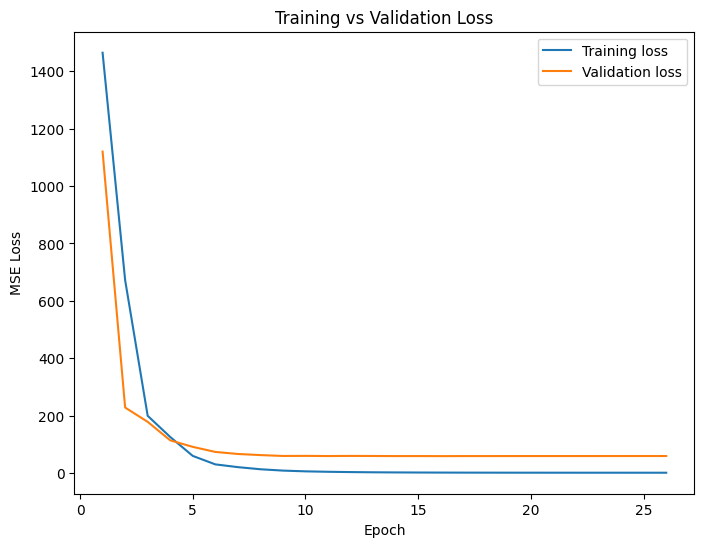

In [67]:
#Plot training vs validation loss
train_loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs_range = range(1, len(train_loss) + 1)

plt.figure(figsize=(8,6))

plt.plot(epochs_range, train_loss, label="Training loss")
plt.plot(epochs_range, val_loss, label="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [68]:
# Predictions
train_preds = model.predict(X_train)
val_preds = model.predict(X_val)
test_preds = model.predict(X_test)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [ ]:
# Evaluate model
train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
val_rmse = np.sqrt(mean_squared_error(y_val, val_preds))
test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))

train_r2 = r2_score(y_train, train_preds)
val_r2 = r2_score(y_val, val_preds)
test_r2 = r2_score(y_test, test_preds)

train_mae = mean_absolute_error(y_train, train_preds)
val_mae = mean_absolute_error(y_val, val_preds)
test_mae = mean_absolute_error(y_test, test_preds)

print("\nTrain Results: ")
print("RMSE:", train_rmse)
print("R2 Score:", train_r2)
print("MAE:", train_mae)

print("\nValidation Results: ")
print("RMSE:", val_rmse)
print("R2 Score:", val_r2)
print("MAE:", val_mae)


print("\nTest Results:")
print("RMSE:", test_rmse)
print("R2 Score:", val_r2)
print("MAE:", test_mae)


Train Results: 
RMSE: 0.6160558151651798
R2 Score: 0.997266948223114

Validation Results: 
RMSE: 7.602737194853174
R2 Score: 0.640487551689148

Test Results:
RMSE: 9.013906119992546
R2 Score: 0.640487551689148


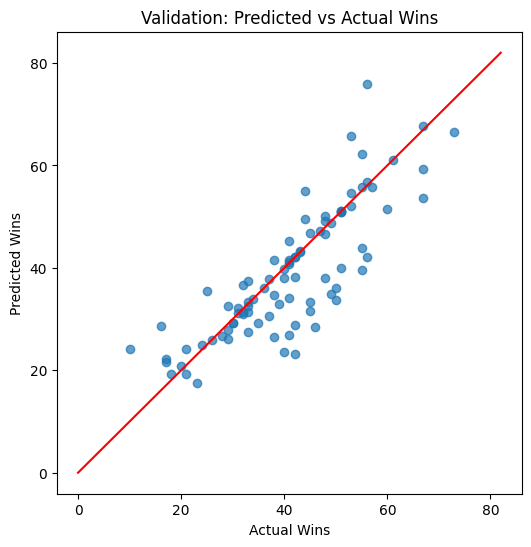

In [70]:
# Validation precdiction graph
plt.figure(figsize=(6,6))

plt.scatter(y_val, val_preds, alpha=0.7)

plt.xlabel("Actual Wins")
plt.ylabel("Predicted Wins")

plt.title("Validation: Predicted vs Actual Wins")

plt.plot([0,82], [0,82], color="red")

plt.show()

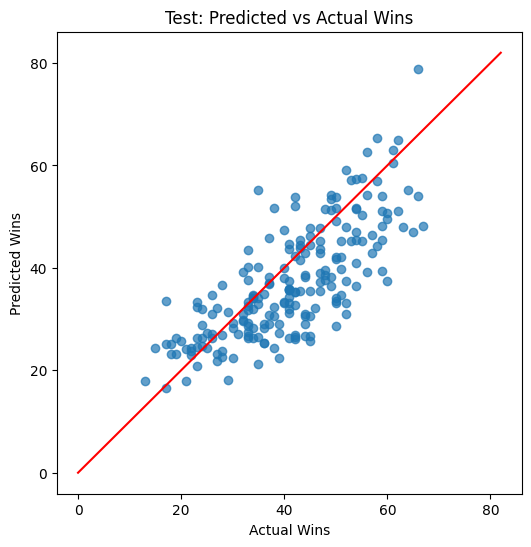

In [71]:
#Test Prediction Graph
plt.figure(figsize=(6,6))

plt.scatter(y_test, test_preds, alpha=0.7)

plt.xlabel("Actual Wins")
plt.ylabel("Predicted Wins")

plt.title("Test: Predicted vs Actual Wins")

plt.plot([0,82], [0,82], color="red")

plt.show()

In [72]:
predictions = pd.DataFrame({
    "Actual Wins": y_test, 
    "Predicted Wins": test_preds.flatten()
})
print("\nSample Predictions")
print(predictions.head())


Sample Predictions
   Actual Wins  Predicted Wins
0         35.0       34.168591
1         44.0       42.853355
2         30.0       28.260492
3         17.0       25.119444
4         60.0       50.693680


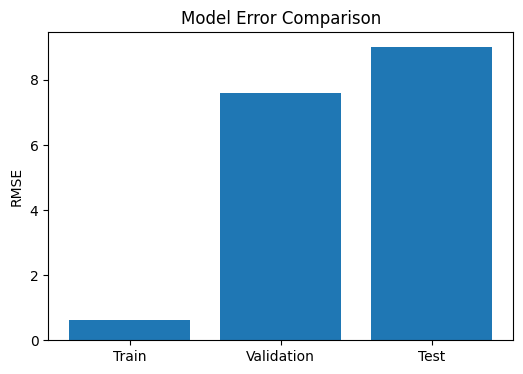

In [73]:
labels = ["Train", "Validation", "Test"]
errors = [train_rmse, val_rmse, test_rmse]

plt.figure(figsize=(6,4))

plt.bar(labels, errors)

plt.ylabel("RMSE")
plt.title("Model Error Comparison")

plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


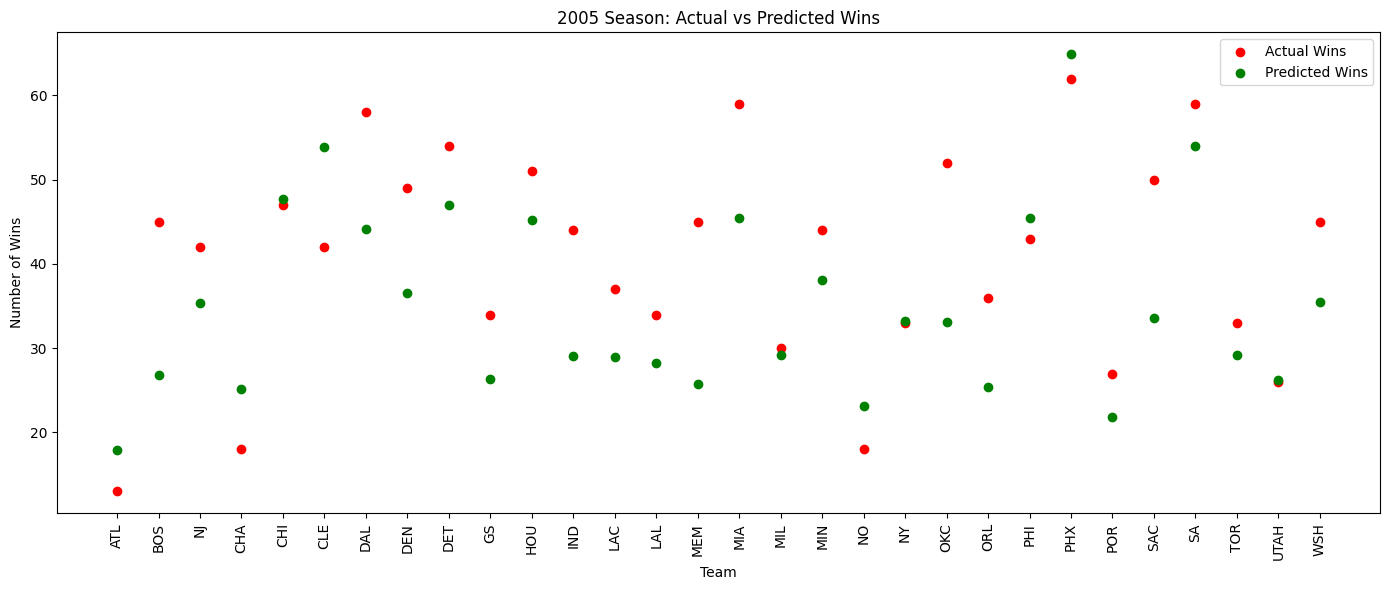

In [74]:
# Get 2005 season data
season_2005 = df[df["season"] == 2005].copy()

X_2005 = season_2005[feature_cols].fillna(0)
y_2005 = season_2005[target]

# Scale using the scaler used on training data
X_2005 = scaler.transform(X_2005)
X_2005 = np.array(X_2005, dtype=np.float32)

# Predict wins
pred_2005 = model.predict(X_2005).flatten()

teams = season_2005["team"].values

# Plot
plt.figure(figsize=(14,6))

plt.scatter(teams, y_2005, color="red", label="Actual Wins")
plt.scatter(teams, pred_2005, color="green", label="Predicted Wins")

plt.xticks(rotation=90)
plt.ylabel("Number of Wins")
plt.xlabel("Team")
plt.title("2005 Season: Actual vs Predicted Wins")

plt.legend()
plt.tight_layout()

plt.show()